# Aitana Euro 2025

In [1]:
# Installing libraries
! pip install statsbombpy --quiet
! pip install mplsoccer --quiet
! pip install networkx --quiet

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from mplsoccer import Pitch, VerticalPitch
import plotly.graph_objects as go
from statsbombpy import sb
import networkx as nx

## Loading Euros data

In [3]:
free_comps = sb.competitions()
free_comps.competition_name.unique()

array(['1. Bundesliga', 'African Cup of Nations', 'Champions League',
       'Copa America', 'Copa del Rey', "FA Women's Super League",
       'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league',
       'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer',
       'North American League', 'NWSL', 'Premier League', 'Serie A',
       'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro",
       "Women's World Cup"], dtype=object)

In [4]:
free_comps[free_comps['competition_name']=="UEFA Women's Euro"]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263


So, `competition_id = 53` and `season_id = 315`.

Getting all the match data from the 2025 Euros

In [5]:
matches = sb.matches(competition_id=53, season_id=315)

In [6]:
matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,4020846,2025-07-27,16:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Spain Women's,1,1,available,...,2025-07-29T16:03:07.355174,6,Final,St. Jakob-Park,Stéphanie Frappart,Sarina Glotzbach-Wiegman,Montserrat Tomé Vázquez,1.1.0,2,2
1,4020077,2025-07-23,19:00:00.000,Europe - UEFA Women's Euro,2025,Germany Women's,Spain Women's,0,1,available,...,2025-07-25T15:22:27.432293,5,Semi-finals,Stadion Letzigrund,Edina Alves Batista,Christian Richard Wück,Montserrat Tomé Vázquez,1.1.0,2,2
2,4020005,2025-07-22,19:00:00.000,Europe - UEFA Women's Euro,2025,England Women's,Italy Women's,2,1,available,...,2025-07-24T13:46:36.152311,5,Semi-finals,Stade de Genève,Ivana Martinčić,Sarina Glotzbach-Wiegman,Andrea Soncin,1.1.0,2,2
3,4018357,2025-07-19,19:00:00.000,Europe - UEFA Women's Euro,2025,France Women's,Germany Women's,1,1,available,...,2025-07-20T21:36:08.622324,4,Quarter-finals,St. Jakob-Park,Tess Olofsson,Laurent Pierre Bonadéi,Christian Richard Wück,1.1.0,2,2
4,4018356,2025-07-18,19:00:00.000,Europe - UEFA Women's Euro,2025,Spain Women's,Switzerland Women's,2,0,available,...,2025-07-19T21:26:11.543565,4,Quarter-finals,Stadion Wankdorf,Maria Sole Ferrieri Caputi,Montserrat Tomé Vázquez,Pia Mariane Sundhage,1.1.0,2,2


In [7]:
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'match_week',
       'competition_stage', 'stadium', 'referee', 'home_managers',
       'away_managers', 'data_version', 'shot_fidelity_version',
       'xy_fidelity_version'],
      dtype='object')

In [8]:
spain_matches = matches[(matches['home_team'] == "Spain Women's") | (matches['away_team'] == "Spain Women's")]

In [9]:
# Extracting Event Data for Spain's matches
all_events = []

for match_id in spain_matches['match_id']:
  events = sb.events(match_id=match_id).reset_index(drop=True)
  all_events.append(events)  # appending all spain events to empty list

spain_df = pd.concat(all_events).reset_index(drop = True)

In [10]:
# Filtering Aitana Bonmati's event data
aitana_df = spain_df[spain_df['player'] == 'Aitana Bonmati Conca']

## 1. Touch Heatmap

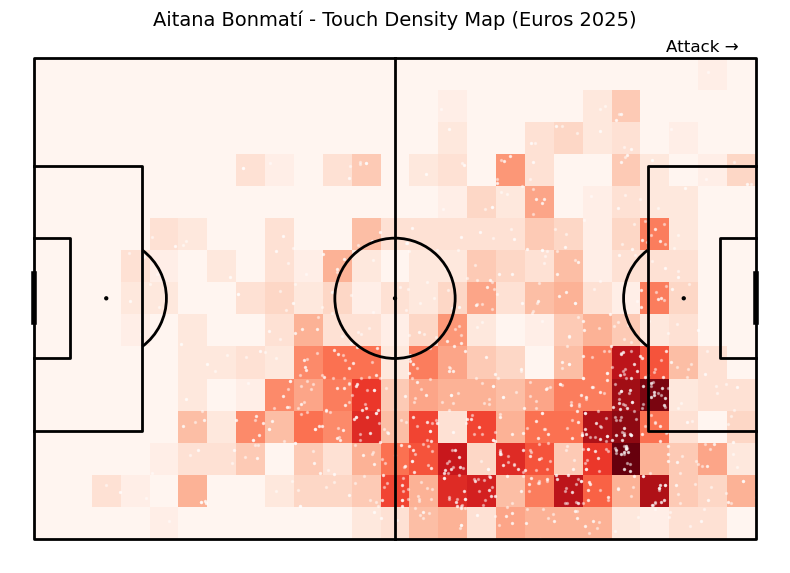

In [11]:
# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', line_zorder=2)
fig, ax = pitch.draw(figsize=(8, 6))

# Extract touch coordinates
x = aitana_df['location'].dropna().apply(lambda x: x[0])
y = aitana_df['location'].dropna().apply(lambda x: x[1])

# Bin the data into 30x20 grid
bin_stat = pitch.bin_statistic(x, y, statistic='count', bins=(25, 15), normalize=False)

# Plot the heatmap
pitch.heatmap(bin_stat, ax=ax, cmap='Reds')
pitch.scatter(x, y, ax=ax, color='white', s=2, alpha=0.4)  # optional scatter overlay

# Add direction of attack arrow
ax.text(105, -1, 'Attack →', color='black', fontsize=12)

# Title
ax.set_title('Aitana Bonmatí - Touch Density Map (Euros 2025)', fontsize=14)
plt.show()


## 2. Pass Network Map

In [12]:
# Filter completed passes
passes = spain_df[(spain_df['type'] == 'Pass') & (spain_df['pass_outcome'].isna())]

# Filter passes involving Aitana
bonmati_passes = passes[(passes['player'] == 'Aitana Bonmati Conca') | (passes['pass_recipient'] == 'Aitana Bonmati Conca')]

In [13]:
# Group by passer-recipient pairs
edges = bonmati_passes.groupby(['player', 'pass_recipient']).agg({
    'id': 'count',
    'location': lambda x: np.mean([i[0] for i in x.dropna()]),
    'pass_end_location': lambda x: np.mean([i[0] for i in x.dropna()])
}).rename(columns={'id': 'pass_count'}).reset_index()

# Filter out self-passes and missing names
edges = edges[(edges['player'].notna()) & (edges['pass_recipient'].notna())]
edges = edges[edges['player'] != edges['pass_recipient']]

In [14]:
# Build graph
G = nx.DiGraph()
for _, row in edges.iterrows():
    G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])

# Compute average position per player
player_locs = {}

for name in pd.concat([bonmati_passes['player'], bonmati_passes['pass_recipient']]).dropna().unique():
    player_events = bonmati_passes[
        (bonmati_passes['player'] == name) | (bonmati_passes['pass_recipient'] == name)
    ]
    x_vals, y_vals = [], []

    for _, row in player_events.iterrows():
        if row['player'] == name and isinstance(row['location'], list):
            x_vals.append(row['location'][0])
            y_vals.append(row['location'][1])
        elif row['pass_recipient'] == name and isinstance(row['pass_end_location'], list):
            x_vals.append(row['pass_end_location'][0])
            y_vals.append(row['pass_end_location'][1])

    if x_vals and y_vals:
        player_locs[name] = (np.mean(x_vals), np.mean(y_vals))

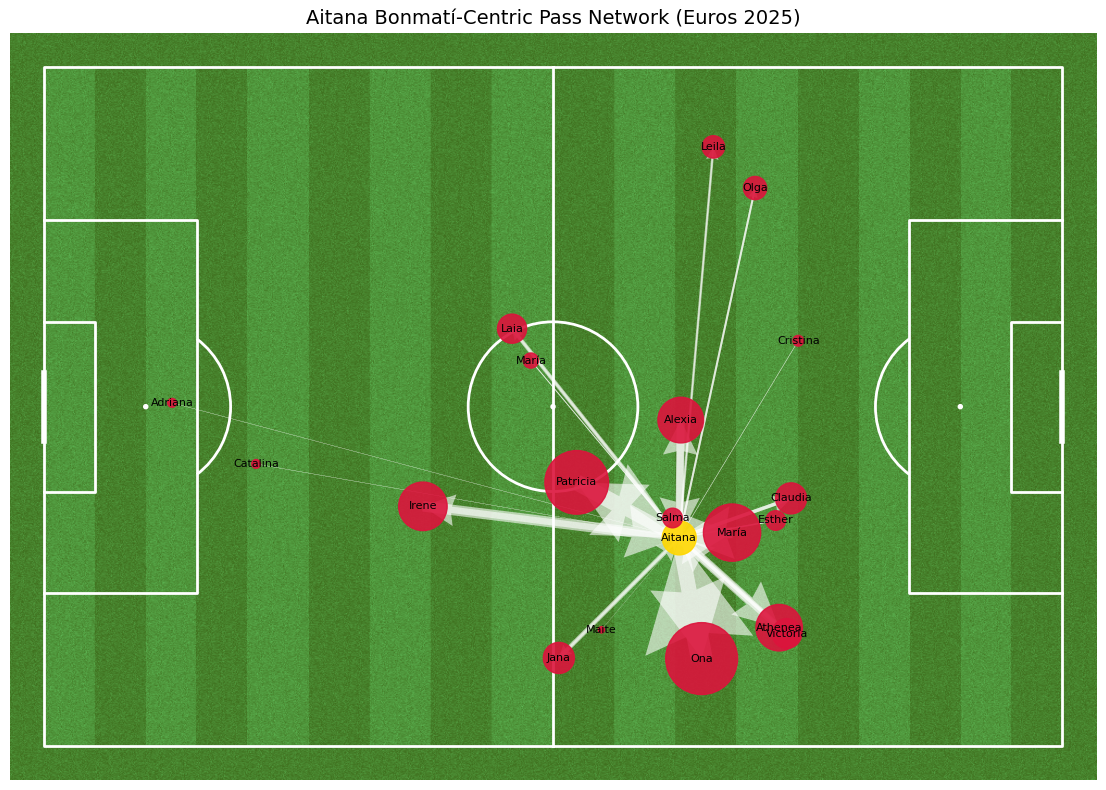

In [15]:
# Draw pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(16, 8))

# Draw edges (arrow width = passes received)
for u, v, d in G.edges(data=True):
    if u in player_locs and v in player_locs:
        width = d['weight'] * 0.2  # Adjust width scale here
        pitch.arrows(player_locs[u][0], player_locs[u][1],
                     player_locs[v][0], player_locs[v][1],
                     ax=ax, width=width, headwidth=5,
                     color='white', alpha=0.6, zorder=1)

# Draw nodes (Bonmatí fixed size & gold, others dynamic & crimson)
node_sizes = []
node_colors = []

for node in G.nodes:
    if node == 'Aitana Bonmati Conca':
        node_sizes.append(600)
        node_colors.append('gold')
    else:
        total_passes = sum([d['weight'] for u, v, d in G.edges(data=True) if u == node or v == node])
        node_sizes.append(total_passes * 20)
        node_colors.append('crimson')

nx.draw_networkx_nodes(G, player_locs, node_size=node_sizes, node_color=node_colors, ax=ax, alpha=0.9)

# Add player names
for player, (x, y) in player_locs.items():
    ax.text(x, y, player.split()[0], fontsize=8, color='black', ha='center', va='center')

# Title
ax.set_title("Aitana Bonmatí-Centric Pass Network (Euros 2025)", fontsize=14, color='black')
plt.show()


## 3. Progressive Actions Flow Map

In [16]:
# Progressive Pass or Carry: movement of at least 10m toward goal and ends in final 60% of pitch
def is_progressive(start, end):
    return (end[0] - start[0]) >= 10 and end[0] >= 60

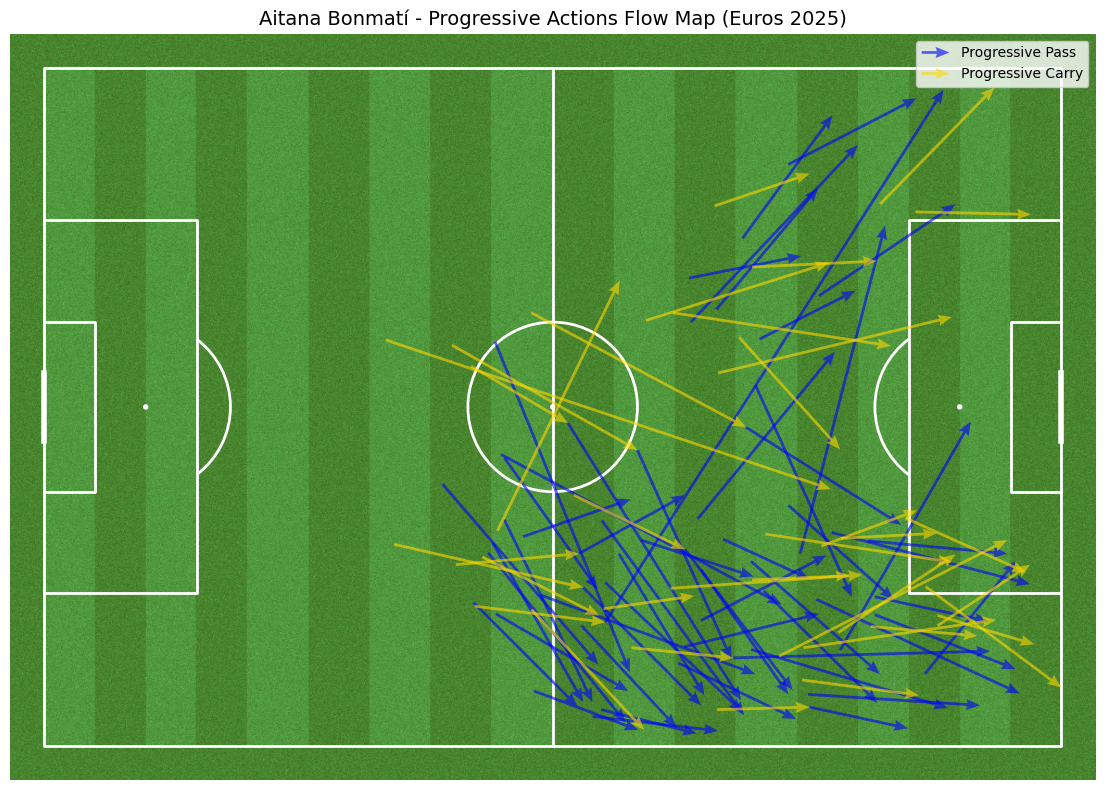

In [17]:
# Filter passes and carries
passes = aitana_df[(aitana_df['type'] == 'Pass') & (aitana_df['pass_outcome'].isna())]
carries = aitana_df[aitana_df['type'] == 'Carry']

# Filter progressive ones
def is_progressive(start, end):
    return isinstance(start, list) and isinstance(end, list) and (end[0] - start[0]) >= 10 and end[0] >= 60

progressive_passes = passes[passes.apply(lambda row: is_progressive(row['location'], row['pass_end_location']), axis=1)]
progressive_carries = carries[carries.apply(lambda row: is_progressive(row['location'], row['carry_end_location']), axis=1)]

# Setup pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(12, 8))

# Plot progressive passes
pitch.arrows(progressive_passes['location'].apply(lambda x: x[0]),
             progressive_passes['location'].apply(lambda x: x[1]),
             progressive_passes['pass_end_location'].apply(lambda x: x[0]),
             progressive_passes['pass_end_location'].apply(lambda x: x[1]),
             ax=ax, color='blue', width=2, headwidth=4, alpha=0.6, label='Progressive Pass')

# Plot progressive carries
pitch.arrows(progressive_carries['location'].apply(lambda x: x[0]),
             progressive_carries['location'].apply(lambda x: x[1]),
             progressive_carries['carry_end_location'].apply(lambda x: x[0]),
             progressive_carries['carry_end_location'].apply(lambda x: x[1]),
             ax=ax, color='gold', width=2, headwidth=4, alpha=0.6, label='Progressive Carry')

# Legend and title
ax.legend(loc='upper right')
ax.set_title("Aitana Bonmatí - Progressive Actions Flow Map (Euros 2025)", fontsize=14, color='black')
plt.show()


In [18]:
# Print stats
print(f"Progressive Passes by Aitana Bonmatí: {len(progressive_passes)}")
print(f"Progressive Carries by Aitana Bonmatí: {len(progressive_carries)}")

Progressive Passes by Aitana Bonmatí: 55
Progressive Carries by Aitana Bonmatí: 36


In [19]:
# Filter all passes by Aitana
passes = aitana_df[aitana_df['type'] == 'Pass']

# Count completed (null 'pass_outcome') and total
completed_passes = passes['pass_outcome'].isna().sum()
total_passes = len(passes)

# Calculate percentage
pass_completion_pct = (completed_passes / total_passes) * 100

print(f"Pass Completion Rate: {pass_completion_pct:.2f}%")
print(f"Completed Passes: {completed_passes} / {total_passes}")

Pass Completion Rate: 86.13%
Completed Passes: 298 / 346


## 4. Passes in the Penalty Box

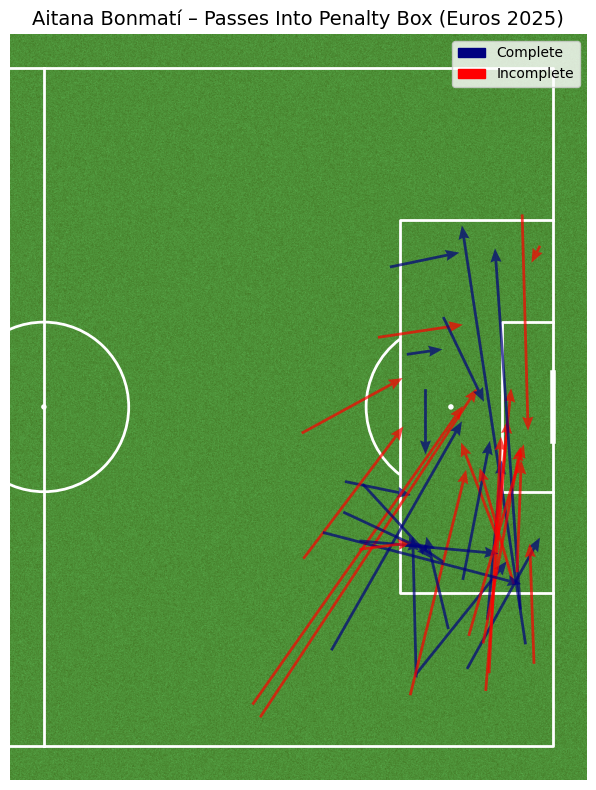

Total Passes into Penalty Box: 37
Breakdown:
outcome
Complete      19
Incomplete    18
Name: count, dtype: int64


In [20]:
from mplsoccer import Pitch
import matplotlib.patches as mpatches

# Define penalty box boundaries
def is_inside_box(end_loc):
    return isinstance(end_loc, list) and end_loc[0] >= 102 and 18 <= end_loc[1] <= 62

# Filter passes into the box
passes = aitana_df[aitana_df['type'] == 'Pass']
box_passes = passes[passes['pass_end_location'].apply(is_inside_box)].copy()

# Set outcome as 'Complete' or use original outcome
box_passes['outcome'] = box_passes['pass_outcome'].fillna('Complete')

# Define color mapping
color_map = {
    'Complete': 'navy',
    'Incomplete': 'red',
    'Out': 'gold',
    'Pass Offside': 'cyan'
}

# Setup pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', half = True)
fig, ax = pitch.draw(figsize=(12, 8))

# Plot arrows
for _, row in box_passes.iterrows():
    outcome = row['outcome']
    color = color_map.get(outcome, 'gray')
    pitch.arrows(row['location'][0], row['location'][1],
                 row['pass_end_location'][0], row['pass_end_location'][1],
                 ax=ax, color=color, width=2, headwidth=4, alpha=0.7)

# Create legend patches based on outcomes present
legend_handles = []
for outcome in box_passes['outcome'].unique():
    if outcome in color_map:
        legend_handles.append(mpatches.Patch(color=color_map[outcome], label=outcome))

# Add legend and title
ax.legend(handles=legend_handles, loc='upper right', fontsize=10)
ax.set_title("Aitana Bonmatí – Passes Into Penalty Box (Euros 2025)", fontsize=14, color='black')
plt.show()

# Stat count
print(f"Total Passes into Penalty Box: {len(box_passes)}")
print("Breakdown:")
print(box_passes['outcome'].value_counts())


## 5. xT

In [21]:
# Load xT Grid
grid_path = 'xT_Grid.csv'
xT_grid = pd.read_csv(grid_path, header=None)
xT = np.array(xT_grid)
xT_rows, xT_cols = xT.shape

In [22]:
# PASSES (successful only)
passes = aitana_df[(aitana_df['type'] == 'Pass') & (aitana_df['pass_outcome'].isna())].copy()
passes['end_location'] = passes['pass_end_location']

# CARRIES (non-null end)
carries = aitana_df[(aitana_df['type'] == 'Carry') & (aitana_df['carry_end_location'].notna())].copy()
carries['end_location'] = carries['carry_end_location']

In [23]:
# Combine & Compute xT
actions = pd.concat([passes, carries], ignore_index=True)
actions = actions[actions['location'].notna() & actions['end_location'].notna()].copy()

# Bin start and end locations
actions['x1_bin'] = pd.cut(actions['location'].apply(lambda x: x[0]), bins=xT_cols, labels=False)
actions['y1_bin'] = pd.cut(actions['location'].apply(lambda x: x[1]), bins=xT_rows, labels=False)
actions['x2_bin'] = pd.cut(actions['end_location'].apply(lambda x: x[0]), bins=xT_cols, labels=False)
actions['y2_bin'] = pd.cut(actions['end_location'].apply(lambda x: x[1]), bins=xT_rows, labels=False)

# Compute xT from grid
actions['start_zone_value'] = actions[['x1_bin','y1_bin']].apply(lambda x: xT[int(x[1]), int(x[0])], axis=1)
actions['end_zone_value'] = actions[['x2_bin','y2_bin']].apply(lambda x: xT[int(x[1]), int(x[0])], axis=1)
actions['xT'] = actions['end_zone_value'] - actions['start_zone_value']

# Print xT summary
print("Aitana Bonmatí generated an xT of", round(float(actions['xT'].sum()), 3), 'in the tournament')


Aitana Bonmatí generated an xT of 1.995 in the tournament


/var/folders/bl/dm6xfp0n2tndy27vk0xjd6jm0000gn/T/ipykernel_19147/186393418.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  actions['start_zone_value'] = actions[['x1_bin','y1_bin']].apply(lambda x: xT[int(x[1]), int(x[0])], axis=1)
/var/folders/bl/dm6xfp0n2tndy27vk0xjd6jm0000gn/T/ipykernel_19147/186393418.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  actions['end_zone_value'] = actions[['x2_bin','y2_bin']].apply(lambda x: xT[int(x[1]), int(x[0])], axis=1)


In [24]:
# Calculating xT per 90
total_xt = actions['xT'].sum()

# Total minutes played
minutes_played = 582  # from FBref

# Compute xT per 90
xt_per_90 = (total_xt / minutes_played) * 90

print(f"Total xT: {total_xt:.3f}")
print(f"Minutes Played: {minutes_played}")
print(f"xT per 90: {xt_per_90:.3f}")


Total xT: 1.995
Minutes Played: 582
xT per 90: 0.309


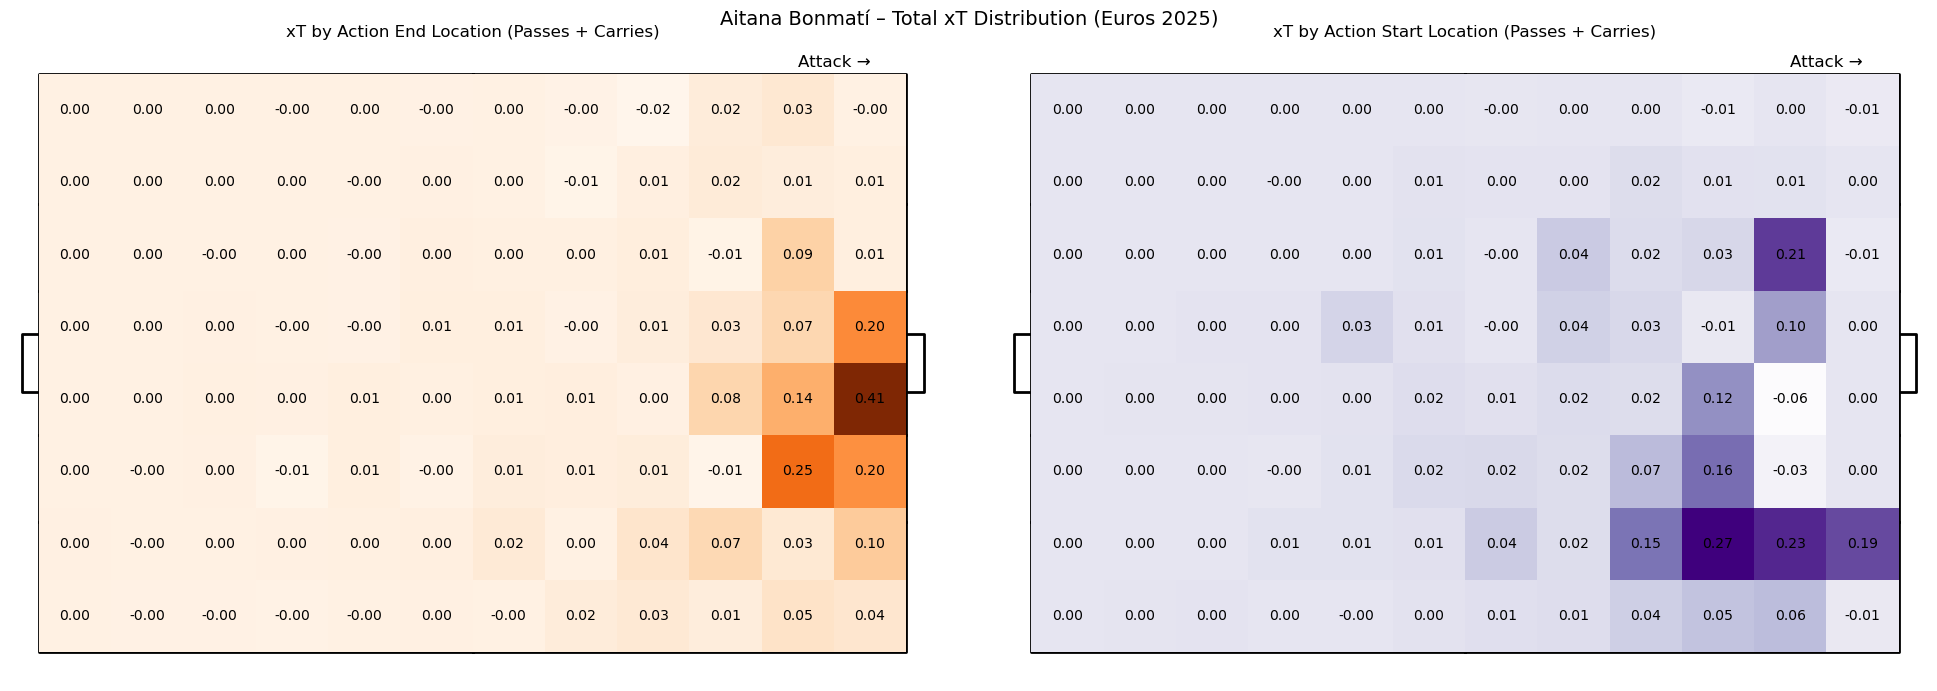

In [25]:
# Setup pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', goal_type='box')
fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(20, 7))

# Coordinates
x_start = actions['location'].apply(lambda x: x[0])
y_start = actions['location'].apply(lambda x: x[1])
x_end = actions['end_location'].apply(lambda x: x[0])
y_end = actions['end_location'].apply(lambda x: x[1])
xt_values = actions['xT']

# END location heatmap
bin_end = pitch.bin_statistic(x_end, y_end, values=xt_values, statistic='sum', bins=(12, 8))
pitch.heatmap(bin_end, ax=axs[0], cmap='Oranges')
pitch.label_heatmap(bin_end, ax=axs[0], color='black', fontsize=10, str_format="{:.2f}")
axs[0].set_title("xT by Action End Location (Passes + Carries)", fontsize=12, color='black')
axs[0].text(105, -1, 'Attack →', color='black', fontsize=12)

# START location heatmap
bin_start = pitch.bin_statistic(x_start, y_start, values=xt_values, statistic='sum', bins=(12, 8))
pitch.heatmap(bin_start, ax=axs[1], cmap='Purples')
pitch.label_heatmap(bin_start, ax=axs[1], color='black', fontsize=10, str_format="{:.2f}")
axs[1].set_title("xT by Action Start Location (Passes + Carries)", fontsize=12, color='black')
axs[1].text(105, -1, 'Attack →', color='black', fontsize=12)

plt.suptitle("Aitana Bonmatí – Total xT Distribution (Euros 2025)", fontsize=14, color='black')
plt.tight_layout()
plt.show()